In [1]:
import arviz as az
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load in the data

This just loads in the data, stores the posterior samples and calculates the WAIC.

The other thing that needs to be done is diagnostic checks to make sure the sampler behaves sensible (e.g. checking it explored the parameter space properly). ArViz has methods for doing this (https://arviz-devs.github.io/arviz/api/diagnostics.html), I'd run all this on the models before but we should probably re-check the modified models.

In [26]:
# Dictionary to store posteriors
posteriors = {}

# Dictionary to store model fit stats, will be turned into a dataframe
waics = {'model': [],
         'kraken': [],
         'waic': [],
         'se': []
         }

# Iterate over models
#for model in ['ucb', 'lcb', 'poi', 'pos', 'post']: # models didn't all run yet so only doing a subset rn
for model in ['ucb', 'pos', 'lcb', 'post']:   
    # Create an empty dict within the dict the results of the model fitting
    posteriors[model] = {}
    
    # Iterate over conditions
    for kraken in [0, 1]:
        
        if model == 'lcb' and kraken == 0: # don't got results for that one yet
            continue
            
        if model == 'post' and kraken == 1: # don't got results for that one yet
            continue
        
        outputs = []
        
        # Iterate over chains and append them to a list
        for runID in range(2):
            outputs.append(az.from_netcdf("C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/results/model_fitting/{2}/model_fit__kraken-{0}_run-{1}.nc".format(kraken, runID, model)))
        
        # Combine the data for the two chains
        dataset = az.concat(*outputs, dim='chain')
        
        # Calculate WAIC
        waic = az.waic(dataset)# there were error here so I addded LOO PIT
        #LOO = az.loo_pit(idata = dataset, y = dataset.observed_data.obs)
        
        # Add necessary data to the WAIC dictionary - this is in effect adding a row to what will become a dataframe
        waics['model'].append(model)
        waics['kraken'].append(kraken)
        waics['waic'].append(waic.waic)
        waics['se'].append(waic.waic_se)
        
        #LOO['model'].append(model)
        #LOO['kraken'].append(kraken)
        #LOO['fit'].append(mean(LOO))
        #LOO['se'].append(np.std(LOO) / np.sqrt(np.size(LOO)))
        
        # Store the posterior
        posteriors[model][kraken] = dataset


C:\Users\Kristin\anaconda3\lib\site-packages\arviz\stats\stats.py:1458: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\Kristin\anaconda3\lib\site-packages\arviz\stats\stats.py:1458: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\Kristin\anaconda3\lib\site-packages\arviz\stats\stats.py:1458: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\Kristin\anaconda3\lib\site-packages\arviz\stats\stats.py:1458: UserWarning: For one or more samples the poste

# Create a dataframe that shows the model fit statistics

Note that ArViz gives the WAIC in a format that means higher = better (in constrast to other information criteria such as BIC where lower = better)

In [27]:
waics = pd.DataFrame(waics)
waics

#LOO = pd.DataFrame(LOO)
#LOO






,model,kraken,waic,se
0,ucb,0,-47216.336343,175.939368
1,ucb,1,-25691.152938,142.936011
2,pos,0,-50732.630219,170.455804
3,pos,1,-25346.158966,165.809111
4,lcb,1,-21429.097833,170.891000
5,post,0,-48762.197592,171.776648


# Plot the model fit statistics

This was set up for the three original models and will need to be changed.

In [ ]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, 2, figsize=(6, 2.8))

ax[0].bar(waics.loc[waics['kraken'] == 0, 'model'], waics.loc[waics['kraken'] == 0, 'waic'], color='#408be6')
ax[0].errorbar(waics.loc[waics['kraken'] == 0, 'model'], waics.loc[waics['kraken'] == 0, 'waic'], yerr=waics.loc[waics['kraken'] == 0, 'se'], fmt='none', color='black', capsize=3)

ax[0].set_title('Kraken absent')
ax[0].set_ylabel('WAIC')
ax[0].set_xlabel('Model')

ax[0].set_xticklabels(['UCB/LCB', 'POI', 'POS'])

ax[1].bar(waics.loc[waics['kraken'] == 1, 'model'], waics.loc[waics['kraken'] == 1, 'waic'], color='#408be6')
ax[1].errorbar(waics.loc[waics['kraken'] == 1, 'model'], waics.loc[waics['kraken'] == 1, 'waic'], yerr=waics.loc[waics['kraken'] == 1, 'se'], fmt='none', color='black', capsize=3)

ax[1].set_title('Kraken absent')
ax[1].set_xlabel('Model')

ax[1].set_xticklabels(['UCB/LCB', 'POI', 'POS'])

plt.tight_layout()

plt.savefig('kraken_model_fit.png')
plt.savefig('kraken_model_fit.pdf')
plt.savefig('kraken_model_fit.svg')

# Extract parameter values

This is set up for the UCB model - it would need to be changed a little for the other models

In [28]:
ucb_kraken_absent = posteriors['ucb'][0].posterior.stack(draws=("chain", "draw"))
ucb_kraken_present = posteriors['ucb'][1].posterior.stack(draws=("chain", "draw"))

NameError: name 'sns' is not defined

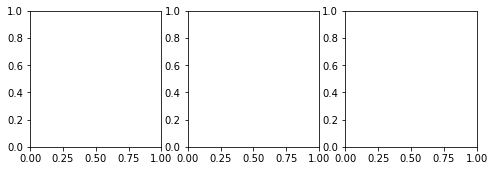

In [29]:
f, ax = plt.subplots(1, 3, figsize=(8, 2.5))
sns.kdeplot(ucb_kraken_absent.ls_subject_transformed.mean(axis=1), color='#408be6', fill=True, clip=[0, 8], label='Absent', ax=ax[0])
sns.kdeplot(ucb_kraken_present.ls_subject_transformed.mean(axis=1), color='#e64064', fill=True, clip=[0, 8], label='Present', ax=ax[0])
ax[0].set_xlim(0, 8)
# ax[0].legend(title='Kraken')
ax[0].set_xlabel('Length scale')

sns.kdeplot(ucb_kraken_absent.beta_subject_transformed.mean(axis=1), color='#408be6', fill=True, label='Absent', ax=ax[1])
sns.kdeplot(ucb_kraken_present.beta_subject_transformed.mean(axis=1), color='#e64064', fill=True, label='Present', ax=ax[1])
# ax[0].set_xlim(0, 8)
# ax[1].legend(title='Kraken')
ax[1].set_xlabel('Beta')
ax[1].axvline(0, linestyle=':', color='gray')
ax[1].set_ylabel('')

sns.kdeplot(ucb_kraken_absent.tau_subject_transformed.mean(axis=1), color='#408be6', fill=True, clip=[0, 0.17], label='Absent', ax=ax[2])
sns.kdeplot(ucb_kraken_present.tau_subject_transformed.mean(axis=1), color='#e64064', fill=True, clip=[0, 0.17], label='Present', ax=ax[2])
ax[2].set_xlim(0, 0.17)
ax[2].legend(title='Kraken')
ax[2].set_xlabel(r'Tau')
ax[2].set_ylabel('')

plt.tight_layout()

# plt.savefig('kraken_params.png')
# plt.savefig('kraken_params.pdf')
# plt.savefig('kraken_params.svg')

# Load original data

This is just to extract the subject IDs so we know which subject is which - the output has subjects in the same order as the original dataset

In [30]:
data = pd.read_csv(
    r"C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/master.csv"
)

# Put the parameter values into a new dataframe

This is also set up for UCB

In [31]:
param_df = {'ID': [],
            'kraken_present': [],
            'ls': [],
            'beta': [],
            'tau': []
           }

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [0] * len(data['ID'].unique())
param_df['ls'] += ucb_kraken_absent.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['beta'] += ucb_kraken_absent.beta_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += ucb_kraken_absent.tau_subject_transformed.mean(axis=1).values.tolist()

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [1] * len(data['ID'].unique())
param_df['ls'] += ucb_kraken_present.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['beta'] += ucb_kraken_present.beta_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += ucb_kraken_present.tau_subject_transformed.mean(axis=1).values.tolist()

param_df = pd.DataFrame(param_df)

# Save

In [32]:
param_df.to_csv('C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/subject_param_estimates_UCB.csv', index=False)

In [33]:
# saving parameter estimates for LCB (only risky version available rn)

lcb_kraken_present = posteriors['lcb'][1].posterior.stack(draws=("chain", "draw"))

param_df = {'ID': [],
            'kraken_present': [],
            'ls': [],
            'beta': [],
            'tau': []
           }

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [1] * len(data['ID'].unique())
param_df['ls'] += lcb_kraken_present.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['beta'] += lcb_kraken_present.beta_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += lcb_kraken_present.tau_subject_transformed.mean(axis=1).values.tolist()

param_df = pd.DataFrame(param_df)

In [34]:
param_df.to_csv('C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/subject_param_estimates_LCB.csv', index=False)

In [38]:
# saving parameter estimates for POS
pos_kraken_absent = posteriors['pos'][0].posterior.stack(draws=("chain", "draw"))
pos_kraken_present = posteriors['pos'][1].posterior.stack(draws=("chain", "draw"))
param_df = {'ID': [],
            'kraken_present': [],
            'ls': [],
            'tau': []
           }

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [0] * len(data['ID'].unique())
param_df['ls'] += pos_kraken_absent.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += pos_kraken_absent.tau_subject_transformed.mean(axis=1).values.tolist()

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [1] * len(data['ID'].unique())
param_df['ls'] += pos_kraken_present.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += pos_kraken_present.tau_subject_transformed.mean(axis=1).values.tolist()

param_df = pd.DataFrame(param_df)
param_df.to_csv('C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/subject_param_estimates_POS.csv', index=False)

In [39]:
# saving parameter estimates for POS-T (only safe condition available for now and tau is in fact overwritten by hmin)

post_kraken_absent = posteriors['post'][0].posterior.stack(draws=("chain", "draw"))

param_df = {'ID': [],
            'kraken_present': [],
            'ls': [],
            'tau': []
           }

param_df['ID'] += data['ID'].unique().tolist()
param_df['kraken_present'] += [0] * len(data['ID'].unique())
param_df['ls'] += post_kraken_absent.ls_subject_transformed.mean(axis=1).values.tolist()
param_df['tau'] += post_kraken_absent.tau_subject_transformed.mean(axis=1).values.tolist()

param_df = pd.DataFrame(param_df)
param_df.to_csv('C:/Users/Kristin/Dropbox/CPI/safeExploration/dataAnalysis/modelFitting/subject_param_estimates_POST.csv', index=False)